# Resource-Rational Navigation in a k-ary Labyrinth
This notebook compares the metabolic cost of a **Cognitive Map (Q-Learning)** against a **Navigation Heuristics** agent. 

The total metabolic cost accounts for the sample inefficiency of learning the map and the dynamic allocation of memory:
$$C_{Total} = \sum (N_{Steps} \times E_{move}) + (B_{Memory} \times E_{comp})$$

Assuming a single step is cheap (1.0), but brain maintenance is expensive (10.0)

In [ ]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from labyrinth import LabyrinthEnv
from Agent import QLearning_agent, HeuristicAgent
import pandas as pd
import networkx as nx

In [2]:
def heuristic_vs_map_experiment(k=2, depth=6, E_move=1.0, E_comp=10.0, verbose=True):
    env = LabyrinthEnv(k=k, depth=depth)
    num_states = env.observation_space.n
    num_actions = env.action_space.n
    optimal_steps = depth * 2 
    
    # EVALUATE MAP AGENT (Q-Learning)
    map_agent = QLearning_agent(num_states, num_actions)
    cumulative_map_steps = 0
    visited_states = set()
    consecutive_perfect_runs = 0
    episodes_to_mastery = 0
    
    for ep in range(5000): 
        obs, info = env.reset()
        done = False
        steps_this_episode = 0
        
        while not done and steps_this_episode < 2000:
            visited_states.add(obs)
            action = map_agent.choose_action(obs)
            next_obs, reward, done, truncated, next_info = env.step(action)
            
            map_agent.learn(obs, action, reward, next_obs, done)
            obs = next_obs
            steps_this_episode += 1
            cumulative_map_steps += 1
            
        episodes_to_mastery += 1
        
        # Force the agent to reduce random exploration even if it timed out
        map_agent.epsilon = max(map_agent.min_epsilon, map_agent.epsilon * map_agent.epsilon_decay)
            
        if steps_this_episode == optimal_steps:
            consecutive_perfect_runs += 1
        else:
            consecutive_perfect_runs = 0
            
        if consecutive_perfect_runs >= 5:
            break
            
    dynamic_memory_bits = len(visited_states) * num_actions * 32
    map_total_cost = (cumulative_map_steps * E_move) + (dynamic_memory_bits * E_comp)
    
    # ==========================================================
    # 2. EVALUATE HEURISTIC AGENT
    # ==========================================================
    heur_agent = HeuristicAgent(k_actions=k)
    heur_memory_bits = heur_agent.memory_bits 
    
    max_allowed_steps = (map_total_cost - (heur_memory_bits * E_comp)) / E_move
    step_limit = min(max_allowed_steps + 10, 500000) 
    
    heur_runs = 100
    total_heur_steps = 0
    hit_early_stop = False
    
    for _ in range(heur_runs):
        obs, info = env.reset()
        done = False
        steps = 0
        
        while not done and steps < step_limit:
            action = heur_agent.choose_action(obs, info['has_water'], info['at_dead_end'])
            obs, reward, done, truncated, info = env.step(action)
            steps += 1
            
        if steps >= step_limit:
            hit_early_stop = True
            
        total_heur_steps += steps
        
    avg_heur_steps = total_heur_steps / heur_runs
    heur_total_cost = (avg_heur_steps * E_move) + (heur_memory_bits * E_comp)
    
    # ==========================================================
    # 3. PRINT RESULTS
    # ==========================================================
    if verbose:
        print(f"Map Cost: {map_total_cost:,.0f} | Heuristic Cost: {heur_total_cost:,.0f}")
        if hit_early_stop:
            print(f"⚠️ EARLY STOP TRIGGERED: Heuristics got lost and exceeded Map Cost.")
            
    return map_total_cost, heur_total_cost

## Phase 1: Replicating Rosenberg et al. (k=2)
Running the baseline experiment on a binary tree labyrinth to verify that local heuristics are metabolically cheaper than building a cognitive map during the exploration phase.

In [3]:
# Run the binary tree (k=2) labyrinth
cost_map, cost_heur = heuristic_vs_map_experiment(k=2, depth=6, E_move=1.0, E_comp=10.0, verbose=True)

Map Cost: 195,110 | Heuristic Cost: 173,764
⚠️ EARLY STOP TRIGGERED: Heuristics got lost and exceeded Map Cost.


# Experimenting with K and Depth

#### Running a k=[2,3,4,5] labyrinth with a depth = [2,3,4]

In [22]:
cost_map, cost_heur = heuristic_vs_map_experiment(k=2, depth=2, E_move=1.0, E_comp=10.0, verbose=True)
cost_map, cost_heur = heuristic_vs_map_experiment(k=3, depth=2, E_move=1.0, E_comp=10.0, verbose=True)
cost_map, cost_heur = heuristic_vs_map_experiment(k=4, depth=2, E_move=1.0, E_comp=10.0, verbose=True)
cost_map, cost_heur = heuristic_vs_map_experiment(k=5, depth=2, E_move=1.0, E_comp=10.0, verbose=True)

Map Cost: 9,709 | Heuristic Cost: 1,354
Map Cost: 22,119 | Heuristic Cost: 1,481
Map Cost: 41,510 | Heuristic Cost: 1,606
Map Cost: 71,050 | Heuristic Cost: 2,027


In [20]:
cost_map, cost_heur = heuristic_vs_map_experiment(k=2, depth=3, E_move=1.0, E_comp=10.0, verbose=True)
cost_map, cost_heur = heuristic_vs_map_experiment(k=3, depth=3, E_move=1.0, E_comp=10.0, verbose=True)
cost_map, cost_heur = heuristic_vs_map_experiment(k=4, depth=3, E_move=1.0, E_comp=10.0, verbose=True)
cost_map, cost_heur = heuristic_vs_map_experiment(k=5, depth=3, E_move=1.0, E_comp=10.0, verbose=True)

Map Cost: 22,096 | Heuristic Cost: 2,156
Map Cost: 71,043 | Heuristic Cost: 9,454
Map Cost: 180,699 | Heuristic Cost: 28,062
Map Cost: 370,559 | Heuristic Cost: 52,304


In [24]:
cost_map, cost_heur = heuristic_vs_map_experiment(k=2, depth=4, E_move=1.0, E_comp=10.0, verbose=True)

Map Cost: 47,798 | Heuristic Cost: 17,029
⚠️ EARLY STOP TRIGGERED: Heuristics got lost and exceeded Map Cost.


### Visualizing Tree Structure
k = [2,3,4,5] and depth = 3

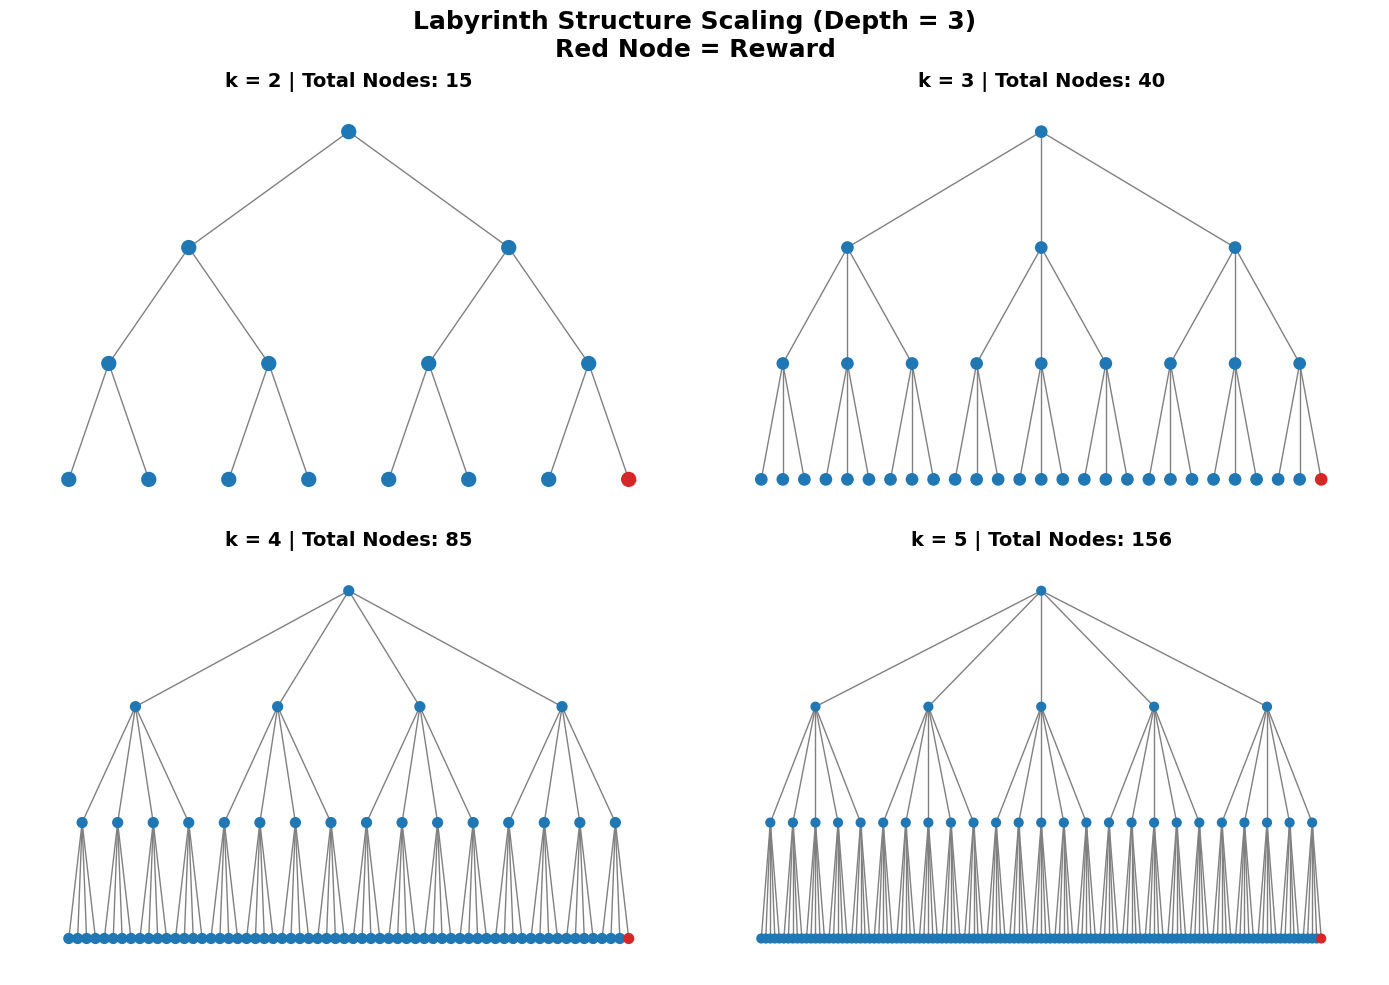

In [ ]:
def plot_labyrinth_grid(k_values, depth=3):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten() # Flattens the 2x2 matrix into a 1D array for easy looping
    
    for idx, k in enumerate(k_values):
        ax = axes[idx]
        num_nodes = (k**(depth + 1) - 1) // (k - 1)
        
        G = nx.DiGraph()
        G.add_nodes_from(range(num_nodes))
        
        for i in range(num_nodes):
            for j in range(1, k + 1):
                child = k * i + j
                if child < num_nodes:
                    G.add_edge(i, child)
                    
        pos = {}
        def assign_positions(node, current_depth, left_bound, right_bound):
            pos[node] = ((left_bound + right_bound) / 2, -current_depth)
            children = [k * node + j for j in range(1, k + 1) if (k * node + j) < num_nodes]
            if children:
                step = (right_bound - left_bound) / len(children)
                for c_idx, child in enumerate(children):
                    child_left = left_bound + (c_idx * step)
                    child_right = child_left + step
                    assign_positions(child, current_depth + 1, child_left, child_right)

        assign_positions(0, 0, 0.0, 1.0)
        
        # Color the goal node red, and all other nodes blue
        goal_node = num_nodes - 1
        node_colors = ['#D62728' if node == goal_node else '#1F77B4' for node in G.nodes()]
        
        # Scale node size so the denser graphs don't become a giant blob
        node_size = max(10, 200 // k)
        
        nx.draw(G, pos, ax=ax, 
                with_labels=False, 
                node_size=node_size, 
                node_color=node_colors, 
                edge_color='gray', 
                arrows=False)
        
        ax.set_title(f"k = {k} | Total Nodes: {num_nodes}", fontsize=14, fontweight='bold')
        ax.axis('off')

    plt.suptitle(f"Labyrinth Structure Scaling (Depth = {depth})\nRed Node = Reward", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the grid visualization!
plot_labyrinth_grid([2, 3, 4, 5], depth=3)

Simulating raw behavior metrics to generate phase space...
Extracting metrics for k=2...
Extracting metrics for k=3...
Extracting metrics for k=4...
Extracting metrics for k=5...


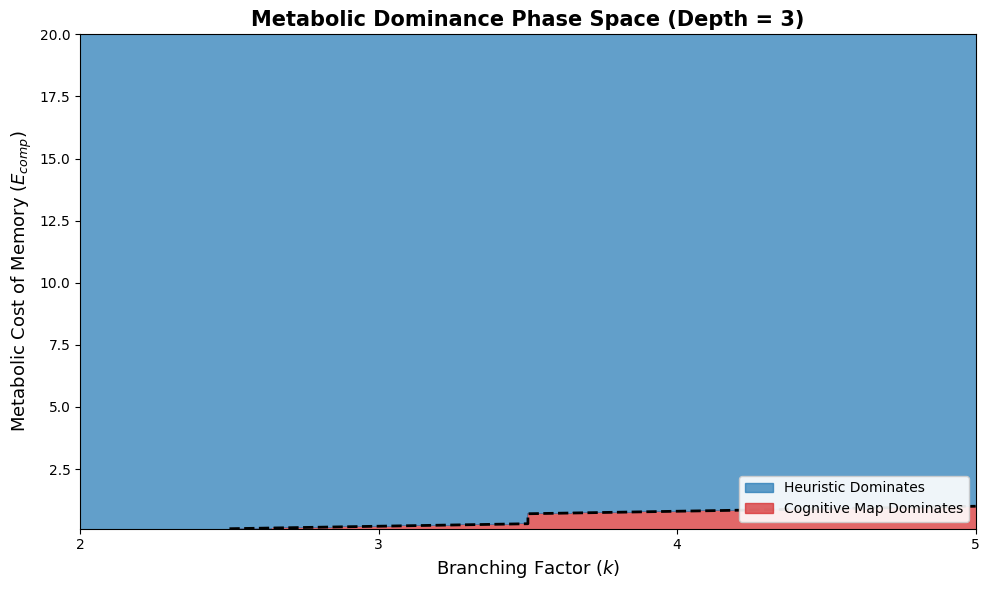

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from labyrinth import LabyrinthEnv
from Agent import QLearning_agent, HeuristicAgent

def plot_metabolic_phase_space(depth=3):
    print("Simulating raw behavior metrics to generate phase space...")
    
    k_values = [2, 3, 4, 5]
    
    # Testing E_comp ratios from 0.1 (Brain is cheap) to 20.0 (Brain is expensive)
    e_comp_range = np.linspace(0.1, 20.0, 100)
    E_move = 1.0 
    
    winner_grid = np.zeros((len(e_comp_range), len(k_values)))
    
    for k_idx, k in enumerate(k_values):
        print(f"Extracting metrics for k={k}...")
        env = LabyrinthEnv(k=k, depth=depth)
        
        # 1. Extract Map Agent Metrics
        map_agent = QLearning_agent(env.observation_space.n, env.action_space.n)
        cumulative_map_steps = 0
        visited_states = set()
        
        for ep in range(300): 
            obs, info = env.reset()
            done = False
            steps = 0
            while not done and steps < 500:
                visited_states.add(obs)
                action = map_agent.choose_action(obs)
                next_obs, reward, done, truncated, next_info = env.step(action)
                map_agent.learn(obs, action, reward, next_obs, done)
                obs = next_obs
                steps += 1
                cumulative_map_steps += 1
            map_agent.epsilon = max(map_agent.min_epsilon, map_agent.epsilon * map_agent.epsilon_decay)
            
        map_memory_bits = len(visited_states) * env.action_space.n * 32
        
        # 2. Extract Heuristic Agent Metrics
        heur_agent = HeuristicAgent(k_actions=k)
        total_heur_steps = 0
        heur_runs = 50
        
        # ---> THE FIX: Calculate a dynamic step limit based on the Map's worst-case cost <---
        max_possible_map_cost = cumulative_map_steps + (map_memory_bits * max(e_comp_range))
        step_limit = int(max_possible_map_cost + 1000)
        
        for _ in range(heur_runs):
            obs, info = env.reset()
            done = False
            steps = 0
            while not done and steps < step_limit:
                action = heur_agent.choose_action(obs, info['has_water'], info['at_dead_end'])
                obs, reward, done, truncated, info = env.step(action)
                steps += 1
            total_heur_steps += steps
            
        avg_heur_steps = total_heur_steps / heur_runs
        heur_memory_bits = heur_agent.memory_bits
        
        # 3. Calculate the algebraic crossover
        for e_idx, E_comp in enumerate(e_comp_range):
            cost_map = (cumulative_map_steps * E_move) + (map_memory_bits * E_comp)
            cost_heur = (avg_heur_steps * E_move) + (heur_memory_bits * E_comp)
            
            if cost_heur < cost_map:
                winner_grid[e_idx, k_idx] = 1 # Heuristic Wins
            else:
                winner_grid[e_idx, k_idx] = 0 # Map Wins

    # 4. Plot the Phase Space Heatmap
    
    plt.figure(figsize=(10, 6))
    
    X, Y = np.meshgrid(k_values, e_comp_range)
    plt.contourf(X, Y, winner_grid, levels=[-0.5, 0.5, 1.5], colors=['#D62728', '#1F77B4'], alpha=0.7)
    plt.contour(X, Y, winner_grid, levels=[0.5], colors=['black'], linewidths=2, linestyles='--')
    
    plt.title(f'Metabolic Dominance Phase Space (Depth = {depth})', fontsize=15, fontweight='bold')
    plt.xlabel('Branching Factor ($k$)', fontsize=13)
    plt.ylabel('Metabolic Cost of Memory ($E_{comp}$)', fontsize=13)
    
    import matplotlib.patches as mpatches
    heur_patch = mpatches.Patch(color='#1F77B4', alpha=0.7, label='Heuristic Dominates')
    map_patch = mpatches.Patch(color='#D62728', alpha=0.7, label='Cognitive Map Dominates')
    plt.legend(handles=[heur_patch, map_patch], loc='lower right', framealpha=0.9)
    
    plt.xticks(k_values)
    plt.tight_layout()
    plt.show()

# Run it
plot_metabolic_phase_space(depth=3)

# Observe behaviour of the Agents


--- STEP-BY-STEP LOG: HEURISTIC AGENT (k=2, depth=3) ---
 Step  Node Dead End? Has Water?          Action Taken
    0     0        No         No Forward (Branch 1) ➡️
    1     2        No         No Forward (Branch 0) ➡️
    2     5        No         No Forward (Branch 1) ➡️
    3    12       Yes         No            Reverse ↩️
    4     5        No         No Forward (Branch 0) ➡️
    5    11       Yes         No            Reverse ↩️
    6     5        No         No Forward (Branch 1) ➡️
    7    12       Yes         No            Reverse ↩️
    8     5        No         No Forward (Branch 0) ➡️
    9    11       Yes         No            Reverse ↩️
   10     5        No         No Forward (Branch 1) ➡️
   11    12       Yes         No            Reverse ↩️
   12     5        No         No Forward (Branch 0) ➡️
   13    11       Yes         No            Reverse ↩️
   14     5        No         No Forward (Branch 1) ➡️
   15    12       Yes         No            Reverse ↩️
   16  

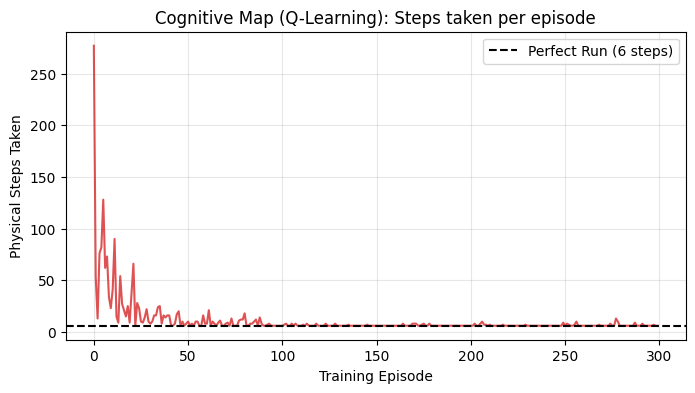

In [ ]:
def watch_heuristic_mouse(k=2, depth=3):
    print(f"\n--- STEP-BY-STEP LOG: HEURISTIC AGENT (k={k}, depth={depth}) ---")
    env = LabyrinthEnv(k=k, depth=depth)
    agent = HeuristicAgent(k_actions=k)
    
    obs, info = env.reset()
    done = False
    step_count = 0
    log = []
    
    while not done and step_count < 100:
        action = agent.choose_action(obs, info['has_water'], info['at_dead_end'])
        
        # Translate the action into readable English
        if action == k:
            action_str = "Reverse ↩️"
        else:
            action_str = f"Forward (Branch {action}) ➡️"
            
        log.append({
            "Step": step_count,
            "Node": info['node'],
            "Dead End?": "Yes" if info['at_dead_end'] else "No",
            "Has Water?": "Yes 💧" if info['has_water'] else "No",
            "Action Taken": action_str
        })
        
        obs, reward, done, truncated, info = env.step(action)
        step_count += 1
        
    # Append the final state
    log.append({
        "Step": step_count,
        "Node": info['node'],
        "Dead End?": "-",
        "Has Water?": "Yes 💧",
        "Action Taken": "🎉 ESCAPED!" if done else "TIMEOUT"
    })
    
    # Print as a nice table
    df = pd.DataFrame(log)
    print(df.to_string(index=False))


def watch_map_agent_learning(k=2, depth=3):
    print(f"\n--- LEARNING CURVE: MAP AGENT (k={k}, depth={depth}) ---")
    env = LabyrinthEnv(k=k, depth=depth)
    agent = QLearning_agent(env.observation_space.n, env.action_space.n)
    
    episode_lengths = []
    
    for ep in range(300): # Watch it for 300 episodes
        obs, info = env.reset()
        done = False
        steps = 0
        
        while not done and steps < 500:
            action = agent.choose_action(obs)
            next_obs, reward, done, truncated, next_info = env.step(action)
            agent.learn(obs, action, reward, next_obs, done)
            obs = next_obs
            steps += 1
            
        # Manually decay epsilon
        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)
        episode_lengths.append(steps)

    # Plot the learning progression
    plt.figure(figsize=(8, 4))
    plt.plot(episode_lengths, color='#D62728', alpha=0.8)
    plt.title('Cognitive Map (Q-Learning): Steps taken per episode', fontsize=12)
    plt.xlabel('Training Episode')
    plt.ylabel('Physical Steps Taken')
    plt.axhline(y=depth*2, color='black', linestyle='--', label='Perfect Run (6 steps)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the diagnostics!
watch_heuristic_mouse(k=2, depth=3)
watch_map_agent_learning(k=2, depth=3)


--- STEPS PER EPISODE: MAP VS HEURISTIC (k=2, depth=3) ---


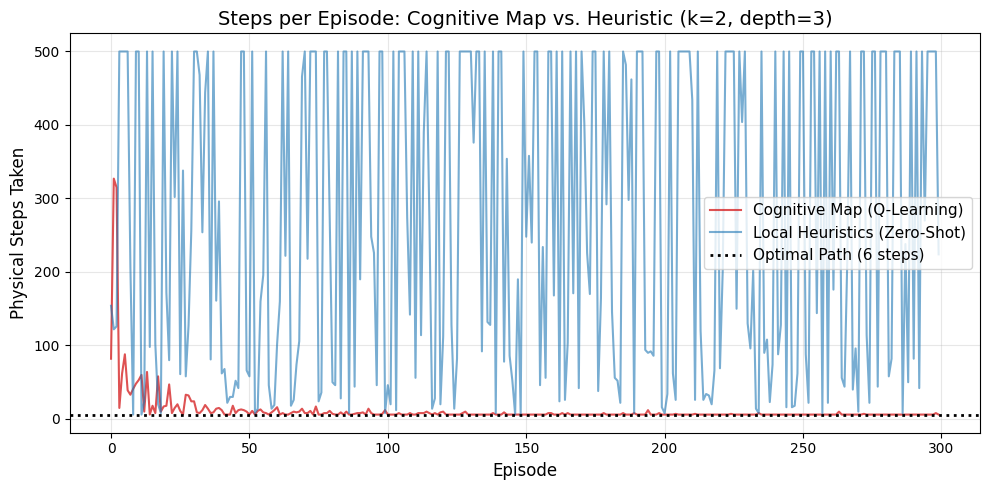

In [26]:
import matplotlib.pyplot as plt

def plot_steps_per_episode(k=2, depth=3, num_episodes=300):
    print(f"\n--- STEPS PER EPISODE: MAP VS HEURISTIC (k={k}, depth={depth}) ---")
    env = LabyrinthEnv(k=k, depth=depth)
    
    # 1. Track Map Agent (Learning over time)
    map_agent = QLearning_agent(env.observation_space.n, env.action_space.n)
    map_steps_per_episode = []
    
    for ep in range(num_episodes): 
        obs, info = env.reset()
        done = False
        steps = 0
        while not done and steps < 500:
            action = map_agent.choose_action(obs)
            next_obs, reward, done, truncated, next_info = env.step(action)
            map_agent.learn(obs, action, reward, next_obs, done)
            obs = next_obs
            steps += 1
            
        map_agent.epsilon = max(map_agent.min_epsilon, map_agent.epsilon * map_agent.epsilon_decay)
        map_steps_per_episode.append(steps)

    # 2. Track Heuristic Agent (Zero-shot variance)
    heur_agent = HeuristicAgent(k_actions=k)
    heur_steps_per_episode = []
    
    for ep in range(num_episodes):
        obs, info = env.reset()
        done = False
        steps = 0
        while not done and steps < 500:
            action = heur_agent.choose_action(obs, info['has_water'], info['at_dead_end'])
            obs, reward, done, truncated, info = env.step(action)
            steps += 1
        heur_steps_per_episode.append(steps)

    # 3. Plotting
    
    plt.figure(figsize=(10, 5))
    
    # Plot both datasets
    plt.plot(map_steps_per_episode, color='#D62728', alpha=0.8, linewidth=1.5, label='Cognitive Map (Q-Learning)')
    plt.plot(heur_steps_per_episode, color='#1F77B4', alpha=0.6, linewidth=1.5, label='Local Heuristics (Zero-Shot)')
    
    # Plot Absolute Minimum
    plt.axhline(y=depth*2, color='black', linestyle=':', linewidth=2, label=f'Optimal Path ({depth*2} steps)')
    
    plt.title(f'Steps per Episode: Cognitive Map vs. Heuristic (k={k}, depth={depth})', fontsize=14)
    plt.xlabel('Episode', fontsize=12)
    plt.ylabel('Physical Steps Taken', fontsize=12)
    
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the plot!
plot_steps_per_episode(k=2, depth=3, num_episodes=300)

In [32]:
def calculate_critical_thresholds(depth=3, max_k=4):
    print(f"--- RUNNING SENSITIVITY ANALYSIS (Depth = {depth}) ---\n")
    
    results = []
    
    for k in range(2, max_k + 1):
        env = LabyrinthEnv(k=k, depth=depth)
        
        # 1. Map Agent Metrics (Training + Memory)
        map_agent = QLearning_agent(env.observation_space.n, env.action_space.n)
        steps_map = 0
        visited_states = set()
        
        for ep in range(300): 
            obs, info = env.reset()
            done = False
            steps = 0
            while not done and steps < 500:
                visited_states.add(obs)
                action = map_agent.choose_action(obs)
                next_obs, reward, done, truncated, next_info = env.step(action)
                map_agent.learn(obs, action, reward, next_obs, done)
                obs = next_obs
                steps += 1
                steps_map += 1
            map_agent.epsilon = max(map_agent.min_epsilon, map_agent.epsilon * map_agent.epsilon_decay)
            
        bits_map = len(visited_states) * env.action_space.n * 32
        
        # 2. Heuristic Agent Metrics (Average execution)
        heur_agent = HeuristicAgent(k_actions=k)
        bits_heur = heur_agent.memory_bits
        
        # We need a dynamic ceiling to let the heuristic fail properly at higher k
        max_map_cost_estimate = steps_map + (bits_map * 20.0)
        step_limit = int(max_map_cost_estimate)
        
        total_heur_steps = 0
        runs = 50
        for _ in range(runs):
            obs, info = env.reset()
            done = False
            steps = 0
            while not done and steps < step_limit:
                action = heur_agent.choose_action(obs, info['has_water'], info['at_dead_end'])
                obs, reward, done, truncated, info = env.step(action)
                steps += 1
            total_heur_steps += steps
            
        steps_heur = total_heur_steps / runs
        
        # 3. Calculate E_critical
        numerator = steps_heur - steps_map
        denominator = bits_map - bits_heur
        
        if denominator == 0:
            e_crit = float('inf')
        else:
            e_crit = numerator / denominator

        # 4. Mathematical Interpretation
        if steps_heur < steps_map and bits_heur < bits_map:
            interpretation = "Strictly Dominant (Heuristic always wins)"
        elif steps_heur > steps_map and e_crit > 0:
            interpretation = f"Map wins if E_comp < {e_crit:.2f}"
        else:
            interpretation = "Indeterminate"

        results.append({
            "Branching (k)": k,
            "Map Steps": f"{steps_map:,.0f}",
            "Heuristic Steps": f"{steps_heur:,.0f}",
            "Map Bits": f"{bits_map:,.0f}",
            "Heur Bits": f"{bits_heur:,.0f}",
            "E_critical": f"{e_crit:.2f}" if e_crit > 0 else "N/A",
            "Conclusion": interpretation
        })
        
    # Output formal table
    df = pd.DataFrame(results)
    
    # Import Jupyter's native display engine
    from IPython.display import display
    
    # Optional: Align the text to the center for better readability
    styled_df = df.style.set_properties(**{'text-align': 'center', 'padding': '12px'}) \
                        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center'), ('font-size', '14px')]}])
    
    display(styled_df)

# Run the mathematical analysis
calculate_critical_thresholds(depth=3, max_k=4)

--- RUNNING SENSITIVITY ANALYSIS (Depth = 3) ---



,Branching (k),Map Steps,Heuristic Steps,Map Bits,Heur Bits,E_critical,Conclusion
0,2,"3,587",999,"2,016",131,N/A,Strictly Dominant (Heuristic always wins)
1,3,"4,136","6,174","6,656",131,0.31,Map wins if E_comp < 0.31
2,4,"7,764","19,423","16,800",131,0.70,Map wins if E_comp < 0.70
